In [ ]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report, confusion_matric, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import FeatureUnion
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

import spacy


from method.utils import *


In [2]:
BASE_DIR = Path.cwd().parent.parent
RESULTS_DIR = BASE_DIR / "Results"
TRAIN_PATH = BASE_DIR / "Ressources" / "Dataset" / "movies"/ "movies1000"
TEST_PATH = BASE_DIR / "Ressources" / "Projet Test Set-20260316" / "testSentiment.txt"

## Chargement des données 

In [3]:
texts, labels, label2id, id2label = load_movies(TRAIN_PATH)
label_names = [id2label[i] for i in sorted(id2label)]

print("Nb textes:", len(texts))
print("Classes:", label2id)

Nb textes: 2000
Classes: {'neg': 0, 'pos': 1}


In [3]:
file = './json_pol.json'
with open(file,encoding="utf-8") as f:
    json_data = json.load(f)

json_texts = [x[0] for x in json_data]
json_labels = [x[1] for x in json_data]

C:\Users\lolin\AppData\Local\Temp\ipykernel_18976\3932514273.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[1].boxplot(by_class, labels=names, patch_artist=True)


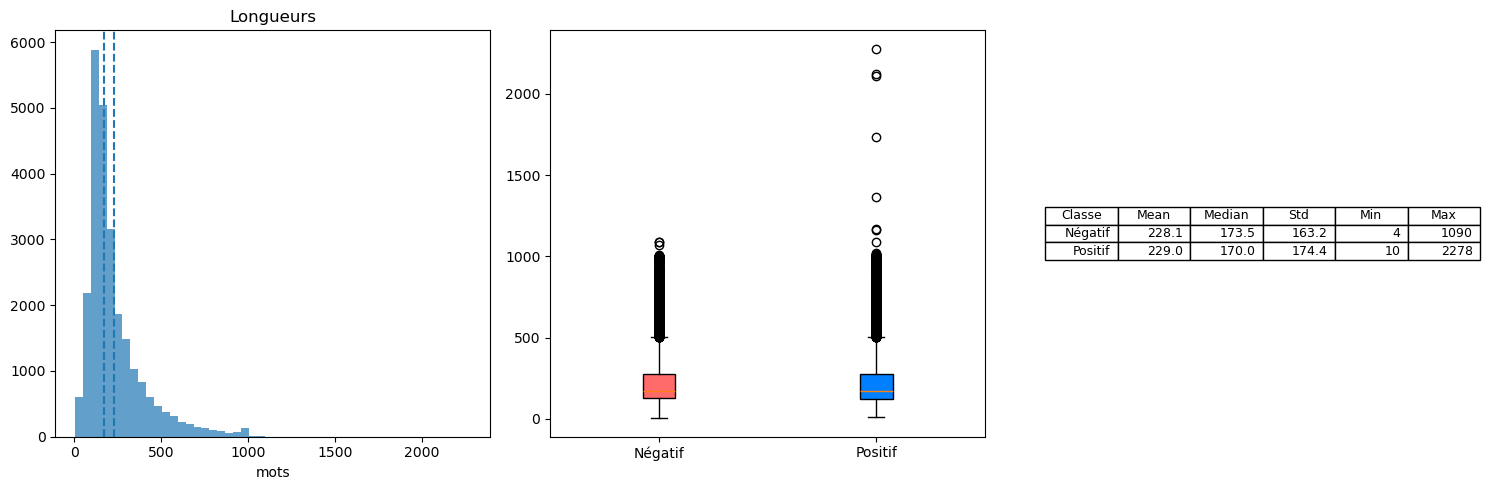

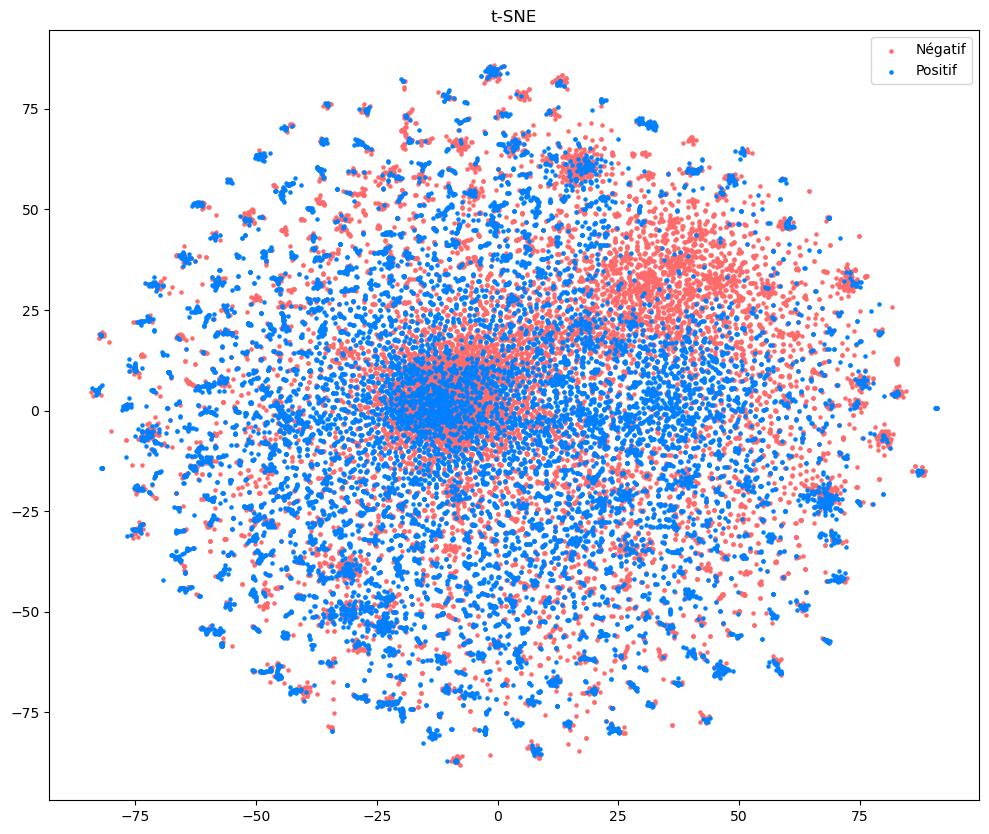


Total: 25000 Neg: 12500 Pos: 12500
Mean: 228.5 Median: 172.0 Std: 168.9


In [4]:

colors = ['#ff6b6b', '#0080FF']
names = ['Négatif', 'Positif']

texts = [str(np.squeeze(t)) for t in json_texts]
labels = np.array([np.squeeze(l) for l in json_labels]).astype(int)

# longueurs
lengths = np.array([len(t.split()) for t in texts])
by_class = [lengths[labels == i] for i in [0, 1]]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].hist(lengths, bins=50, alpha=0.7)
ax[0].axvline(lengths.mean(), ls='--')
ax[0].axvline(np.median(lengths), ls='--')
ax[0].set(title="Longueurs", xlabel="mots")

bp = ax[1].boxplot(by_class, labels=names, patch_artist=True)
for b, c in zip(bp['boxes'], colors):
    b.set_facecolor(c)

stats = pd.DataFrame({
    'Classe': names,
    'Mean': [x.mean() for x in by_class],
    'Median': [np.median(x) for x in by_class],
    'Std': [x.std() for x in by_class],
    'Min': [x.min() for x in by_class],
    'Max': [x.max() for x in by_class],
})

ax[2].axis('off')
ax[2].table(cellText=stats.round(1).values, colLabels=stats.columns, loc='center')

plt.tight_layout()
plt.savefig('stats.png')
plt.show()

# t-sne 
vec = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X = vec.fit_transform(texts)

if len(texts) > 30:
    X2d = TSNE(2, perplexity=min(30, len(texts)-1), random_state=42).fit_transform(X.toarray())
    plt.figure(figsize=(12, 10))
    for i, c, n in zip([0, 1], colors, names):
        plt.scatter(*X2d[labels == i].T, c=c, label=n, s=5)
    plt.legend()
    plt.title("t-SNE")
    plt.savefig('tsne.png')
    plt.show()


counts = np.bincount(labels)
print(f"\nTotal: {len(texts)} Neg: {counts[0]} Pos: {counts[1]}")
print(f"Mean: {lengths.mean():.1f} Median: {np.median(lengths):.1f} Std: {lengths.std():.1f}")

In [ ]:
import string
# !python -m spacy download en_core_web_sm
nlp = spacy.load('en_core_web_sm') 

def cleanX(text):
    text = text.lower()
    
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    doc = nlp(text)
    text = ' '.join([token.lemma_ for token in doc])
    
    return text


cleaned_texts = [cleanX(text) for text in texts]


neg_texts = [cleaned_texts[i] for i in range(len(labels)) if labels[i] == 0]
pos_texts = [cleaned_texts[i] for i in range(len(labels)) if labels[i] == 1]



     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------ --------------------------------- 2.1/12.8 MB 10.1 MB/s eta 0:00:02
     -------------- ------------------------- 4.7/12.8 MB 11.5 MB/s eta 0:00:01
     ---------------------- ----------------- 7.1/12.8 MB 11.2 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.8 MB 11.4 MB/s eta 0:00:01
     ------------------------------------ -- 12.1/12.8 MB 11.3 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 10.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Dix textes nettoyés : in an early scene luca david pasquesi and james jeff garlin be walk down a neighborhood street in chicago admire the bucolic architecture when a woman angrily argue in french on a cell phone pass by they prompt jame to remark there s nothing hot than an angry french woman a few block later they pass an old filipino woman al

Vectorisation TF-IDF...
Matrice TF-IDF shape: (25000, 5000)
Application de t-SNE (peut prendre 10-30 minutes)...


c:\Users\lolin\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


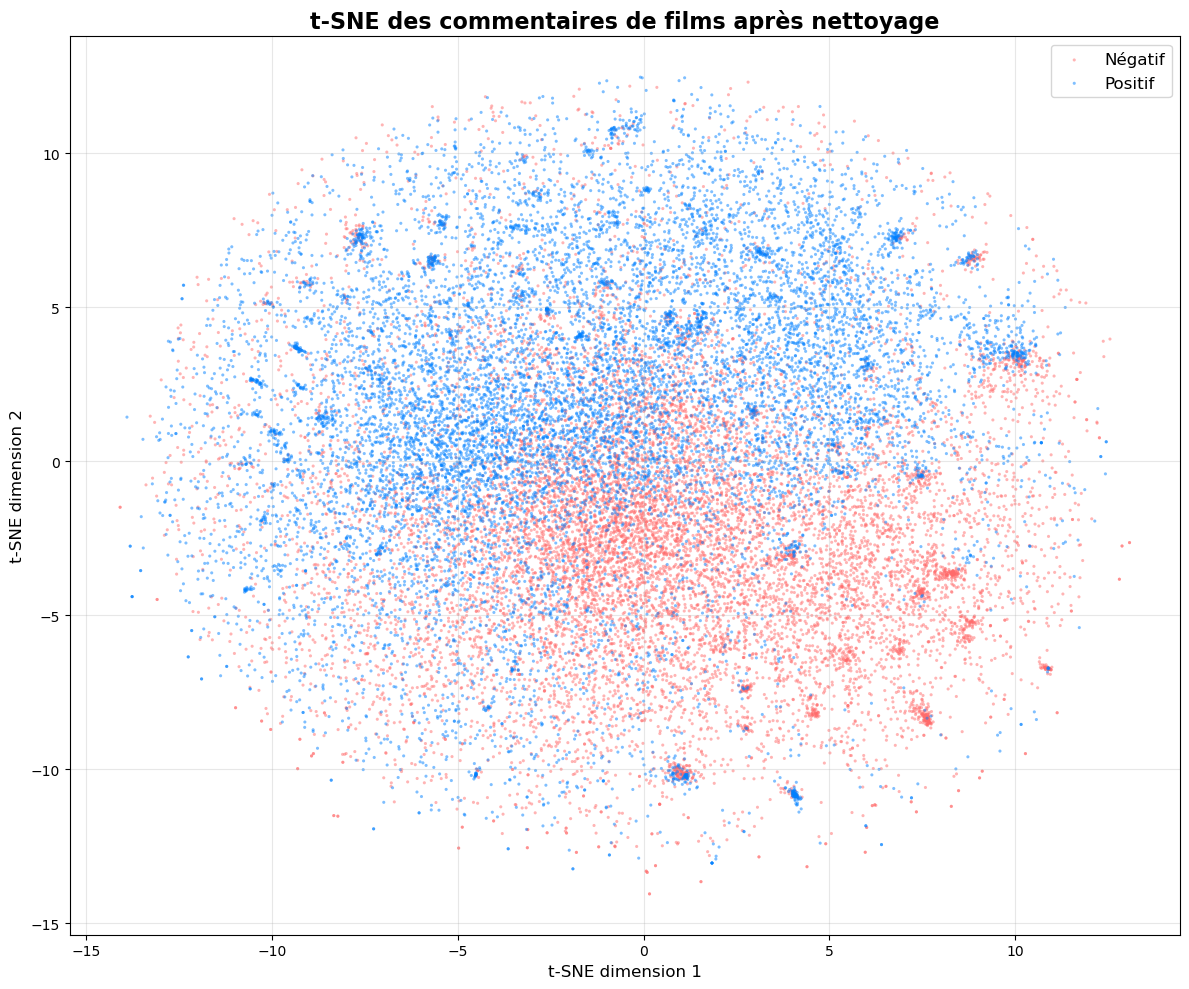

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.8,
    sublinear_tf=True
)

tfidf_matrix = vectorizer.fit_transform(cleaned_texts)
print(f"Matrice TF-IDF shape: {tfidf_matrix.shape}")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tfidf_tsne = tsne.fit_transform(tfidf_matrix.toarray())

colors = ['#ff6b6b', '#0080FF']
class_names = ['Négatif', 'Positif']

fig, ax = plt.subplots(figsize=(12, 10))

for label, color, name in zip([0, 1], colors, class_names):
    mask = np.array(labels) == label
    ax.scatter(tfidf_tsne[mask, 0], tfidf_tsne[mask, 1], 
               c=color, label=name, alpha=0.5, s=5, edgecolors='none')

ax.set_title('t-SNE des commentaires de films après nettoyage', fontsize=16, fontweight='bold')
ax.set_xlabel('t-SNE dimension 1', fontsize=12)
ax.set_ylabel('t-SNE dimension 2', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsne_cleaned.png', dpi=300, bbox_inches='tight')
plt.show()

## TF-IDF + Régression linéaire et SVM

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    json_texts, json_labels, test_size=0.2, random_state=42, stratify=json_labels, shuffle=True
)


In [23]:
models = {
    #"logreg": LogisticRegression(max_iter=3000),
    "svm": LinearSVC(C=1)
}


best_model_name = None
best_score = 0
best_pipeline = None


for name, clf in models.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(# stop_words=stop_words, 
                                  # preprocessor = ti_utils.preprocess_text,
                                  # analyzer="char",
                                  # ngram_range=(3,5), 
                                  ngram_range=(1,3),
                                  min_df=3,
                                  max_df=0.8,
                                  max_features = 10000,
                                  sublinear_tf=True
                                    )
                                  ),
        #("tfidf", TfidfVectorizer(ngram_range=(3,5), max_features=30000, analyzer="char", sublinear_tf=True)),
        ("clf", clf)
    ])


    pipe.fit(X_train,y_train)
    train_preds = pipe.predict(X_train)
    val_preds = pipe.predict(X_val)

    train_f1 = f1_score(y_train, train_preds, average="macro")
    val_f1 = f1_score(y_val, val_preds, average="macro")

    print(f"\n{name}")
    print(f"Train F1: {train_f1:.4f}")
    print(f"Val F1:   {val_f1:.4f}")
    print(classification_report(y_val, val_preds, digits=4))

    if val_f1 > best_score:
        best_score = val_f1
        best_model_name = name
        best_pipeline = pipe

print(f"\nBest model: {best_model_name} (F1: {best_score:.4f})")






svm
Train F1: 0.9849
Val F1:   0.8896
              precision    recall  f1-score   support

           0     0.8880    0.8916    0.8898      2500
           1     0.8912    0.8876    0.8894      2500

    accuracy                         0.8896      5000
   macro avg     0.8896    0.8896    0.8896      5000
weighted avg     0.8896    0.8896    0.8896      5000


Best model: svm (F1: 0.8896)


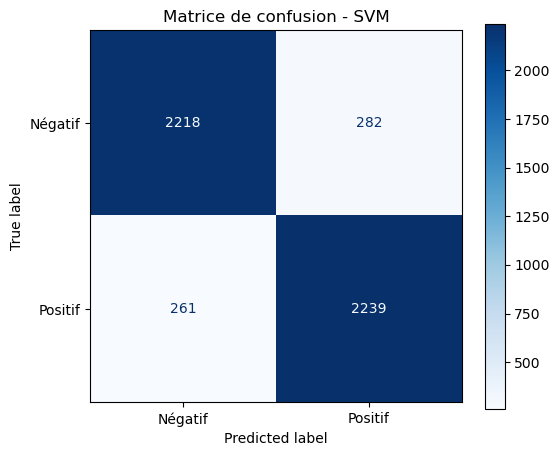

In [22]:


cm = confusion_matrix(y_val, val_preds)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Négatif', 'Positif']).plot(ax=ax, cmap='Blues')
ax.set_title('Matrice de confusion - SVM')
plt.savefig('confusion_matrix_svm_films.png', dpi=300)
plt.show()

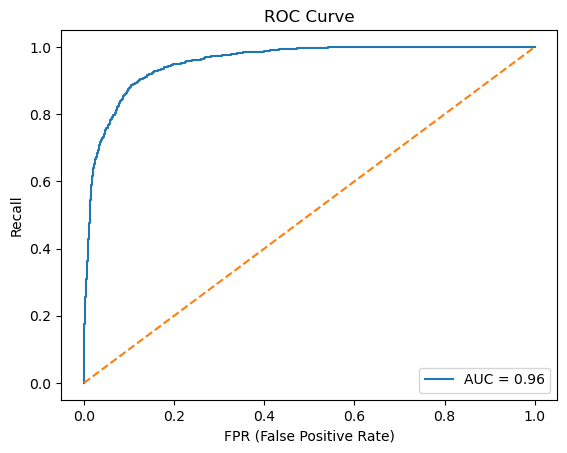

In [26]:
from sklearn.metrics import roc_curve, auc

y_score = best_pipeline.decision_function(X_val)

fpr, tpr, _ = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("Recall")
plt.legend()
plt.title("ROC Curve")
plt.show()

In [27]:
best_pipeline.fit(json_texts,json_labels)
# joblib.dump(best_pipeline, "tf_idf_svm_movies_lemm2.pkl")
print("saved")

saved


## On teste le modèle sur l'ensemble du TME 1 

In [16]:
test_texts, test_labels, _, _ = load_movies(TRAIN_PATH)
# test_texts = [ti_utils.preprocess_movie(t) for t in test_texts]

Accuracy: 0.8855
F1 macro: 0.8854896654423061

=== PER CLASS METRICS ===
              precision    recall  f1-score   support

           0     0.8930    0.8760    0.8844      1000
           1     0.8783    0.8950    0.8866      1000

    accuracy                         0.8855      2000
   macro avg     0.8856    0.8855    0.8855      2000
weighted avg     0.8856    0.8855    0.8855      2000



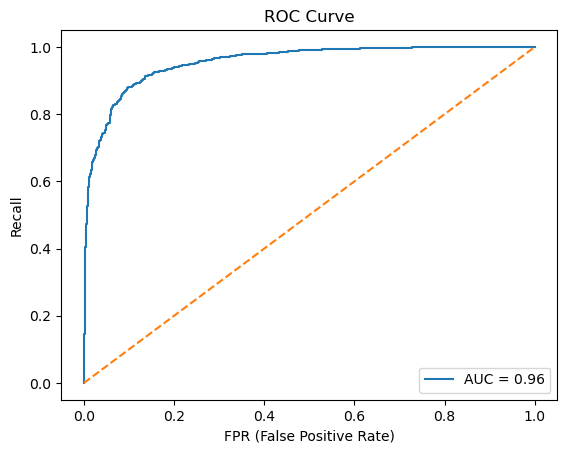

In [17]:
test_preds = best_pipeline.predict(test_texts)


print("Accuracy:", accuracy_score(test_labels, test_preds))
print("F1 macro:", f1_score(test_labels, test_preds, average="macro"))

print("\n=== PER CLASS METRICS ===")
print(classification_report(test_labels, test_preds, digits=4))


if hasattr(best_pipeline, "decision_function"):
    scores = best_pipeline.decision_function(test_texts)
else:
    scores = best_pipeline.predict_proba(test_texts)[:, 1]

fpr, tpr, _ = roc_curve(test_labels, scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("Recall")
plt.legend()
plt.title("ROC Curve")
plt.show()

### Full training 

In [28]:
all_texts = json_texts + test_texts
all_labels = json_labels + test_labels



In [ ]:
# best_pipeline.fit(all_texts,all_labels)

test_set= load_test_file(TEST_PATH)
preds = best_pipeline.predict(test_set)

mapped_preds = ["P" if p == 1 else "N" for p in preds]

df = pd.DataFrame(mapped_preds)
df.to_csv("submission-movie-4.csv", index=False, header=False)

## 

In [140]:
STOPWORDS_OPTIONS = {
        "no_stopwords": None,
        "custom_stopwords": get_custom_stopwords(),
    }

SKLEARN_MODELS = ["linearSVC", "logreg", "multinomialnb"]

PREPROCESSINGS = {
        "raw_minimal": clean_raw_minimal,
        "keep_negation": clean_keep_negation,
        "light": clean_light,
    }

BILSTM_PREPROCESSINGS = {
        "keep_negation": clean_keep_negation,
        "light": clean_light,
    }

TRANSFORMER_PREPROCESSINGS = {
        "raw_minimal": clean_raw_minimal,
        "keep_negation": clean_keep_negation,
    }

all_results = []

In [141]:

for clean_name, clean_fn in PREPROCESSINGS.items():
    for sw_name, sw_value in STOPWORDS_OPTIONS.items():
        X_train_clean = apply_cleaning_with_stopwords(X_train_raw, clean_fn, sw_value)
        X_val_clean = apply_cleaning_with_stopwords(X_val_raw, clean_fn, sw_value)
        X_test_clean = apply_cleaning_with_stopwords(X_test_raw, clean_fn, sw_value)

        for model_name in SKLEARN_MODELS:
            family = "sklearn"
            print(f"\n>>> {model_name} | {clean_name} | {sw_name} | default")

            pipeline = build_sklearn_pipeline(model_name, sw_value, tuned=False)

            model, _ = train_or_load_sklearn_model(
                family=family,
                model_name=model_name,
                clean_name=clean_name,
                stopwords_name=sw_name,
                pipeline=pipeline,
                X_train=X_train_clean,
                y_train=y_train,
            )

            res = evaluate_sklearn_model(
                family=family,
                model_name=model_name,
                clean_name=clean_name,
                stopwords_name=sw_name,
                model=model,
                X_train=X_train_clean,
                y_train=y_train,
                X_val=X_val_clean,
                y_val=y_val,
                X_test=X_test_clean,
                y_test=y_test,
                label_names=label_names,
                do_cv=True,
                cv=5,
            )

            all_results.append(res)


>>> linearSVC | raw_minimal | no_stopwords | default
[TRAIN] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\sklearn__linearSVC__raw_minimal__no_stopwords.joblib
[SAVE] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\sklearn__linearSVC__raw_minimal__no_stopwords.joblib

>>> logreg | raw_minimal | no_stopwords | default
[TRAIN] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\sklearn__logreg__raw_minimal__no_stopwords.joblib
[SAVE] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\sklearn__logreg__raw_minimal__no_stopwords.joblib

>>> multinomialnb | raw_minimal | no_stopwords | default
[TRAIN] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\sklearn__multinomialnb__raw_minimal__no_stopwords.joblib
[SAVE] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\sklearn__multinomialnb__raw_minimal__no_stopwords.joblib

>>> linearSVC | raw_minimal | custom_stopwords | default
[TRAIN] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\sklearn__linearSVC__raw_minimal__custom_stopwords.joblib

## RNN

In [143]:
for clean_name, clean_fn in BILSTM_PREPROCESSINGS.items():
    for sw_name, sw_value in STOPWORDS_OPTIONS.items():
        family = "keras"
        model_name = "BiLSTM"

        print(f"\n>>> {model_name} | {clean_name} | {sw_name}")

        X_train_clean = apply_cleaning_with_stopwords(X_train_raw, clean_fn, sw_value)
        X_val_clean = apply_cleaning_with_stopwords(X_val_raw, clean_fn, sw_value)
        X_test_clean = apply_cleaning_with_stopwords(X_test_raw, clean_fn, sw_value)

        model_path = keras_model_path(family, model_name, clean_name, sw_name)
        tokenizer_path = model_path.replace(".keras", "_tokenizer.json")

        if os.path.exists(model_path) and os.path.exists(tokenizer_path):
            print(f"[LOAD] {model_path}")
            lstm_model = load_model(model_path)
            tokenizer = load_tokenizer_from_json(tokenizer_path)
        else:
            print(f"[TRAIN] {model_path}")
            tokenizer = prepare_lstm_tokenizer(X_train_clean, max_words=MAX_WORDS)

            X_train_pad = texts_to_padded(tokenizer, X_train_clean, max_len=MAX_LEN)
            X_val_pad = texts_to_padded(tokenizer, X_val_clean, max_len=MAX_LEN)

            y_train_np = np.array(y_train)
            y_val_np = np.array(y_val)

            lstm_model = build_bilstm_model(
                max_words=MAX_WORDS,
                max_len=MAX_LEN,
                embed_dim=64,
            )

            early_stop = EarlyStopping(
                monitor="val_loss",
                patience=1,
                restore_best_weights=True,
                verbose=1,
            )

            reduce_lr = ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=1,
                min_lr=1e-6,
                verbose=1,
            )

            history = lstm_model.fit(
                X_train_pad,
                y_train_np,
                validation_data=(X_val_pad, y_val_np),
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                callbacks=[early_stop, reduce_lr],
                verbose=1,
            )

            lstm_model.save(model_path)
            save_tokenizer(tokenizer, tokenizer_path)

            history_base = history_plot_path(family, model_name, clean_name, sw_name)
            save_keras_history_plot(history, history_base)

        X_train_pad = texts_to_padded(tokenizer, X_train_clean, max_len=MAX_LEN)
        X_val_pad = texts_to_padded(tokenizer, X_val_clean, max_len=MAX_LEN)
        X_test_pad = texts_to_padded(tokenizer, X_test_clean, max_len=MAX_LEN)

        y_train_np = np.array(y_train)
        y_val_np = np.array(y_val)
        y_test_np = np.array(y_test)

        y_train_proba = lstm_model.predict(X_train_pad, verbose=0).ravel()
        y_val_proba = lstm_model.predict(X_val_pad, verbose=0).ravel()
        y_test_proba = lstm_model.predict(X_test_pad, verbose=0).ravel()

        y_train_pred = (y_train_proba >= 0.5).astype(int)
        y_val_pred = (y_val_proba >= 0.5).astype(int)
        y_test_pred = (y_test_proba >= 0.5).astype(int)

        train_acc = accuracy_score(y_train_np, y_train_pred)
        val_acc = accuracy_score(y_val_np, y_val_pred)
        test_acc = accuracy_score(y_test_np, y_test_pred)

        train_f1 = f1_score(y_train_np, y_train_pred, average="macro")
        val_f1 = f1_score(y_val_np, y_val_pred, average="macro")
        test_f1 = f1_score(y_test_np, y_test_pred, average="macro")

        train_loss = float(log_loss(y_train_np, np.vstack([1 - y_train_proba, y_train_proba]).T))
        val_loss = float(log_loss(y_val_np, np.vstack([1 - y_val_proba, y_val_proba]).T))
        test_loss = float(log_loss(y_test_np, np.vstack([1 - y_test_proba, y_test_proba]).T))

        cm_path = confusion_path(family, model_name, clean_name, sw_name)
        save_confusion_matrix(
            y_test_np,
            y_test_pred,
            label_names,
            cm_path,
            title=f"{model_name} | {clean_name} | {sw_name}"
        )

        rep = {
            "family": family,
            "model_name": model_name,
            "clean_name": clean_name,
            "stopwords_name": sw_name,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc,
            "test_accuracy": test_acc,
            "train_f1": train_f1,
            "val_f1": val_f1,
            "test_f1": test_f1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "test_loss": test_loss,
            "cv_f1_mean": None,
            "cv_f1_std": None,
            "classification_report": classification_report(
                y_test_np, y_test_pred, target_names=label_names, output_dict=True
            ),
            "model_path": model_path,
            "confusion_matrix_path": cm_path,
        }

        rep_p = report_path(family, model_name, clean_name, sw_name)
        save_report_json(rep, rep_p)

        all_results.append(
            ExperimentResult(
                family=family,
                model_name=model_name,
                clean_name=clean_name,
                stopwords_name=sw_name,
                train_accuracy=train_acc,
                val_accuracy=val_acc,
                test_accuracy=test_acc,
                train_f1=train_f1,
                val_f1=val_f1,
                test_f1=test_f1,
                train_loss=train_loss,
                val_loss=val_loss,
                test_loss=test_loss,
                cv_f1_mean=None,
                cv_f1_std=None,
                model_path=model_path,
                report_path=rep_p,
                confusion_matrix_path=cm_path,
            )
        )


>>> BiLSTM | keep_negation | no_stopwords
[TRAIN] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\keras__BiLSTM__keep_negation__no_stopwords.keras
Epoch 1/5


c:\Users\yeyuy\anaconda3\envs\dalas\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 146ms/step - accuracy: 0.5008 - loss: 0.6980 - val_accuracy: 0.5156 - val_loss: 0.6980 - learning_rate: 3.0000e-04
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.5352 - loss: 0.6952 - val_accuracy: 0.5094 - val_loss: 0.6977 - learning_rate: 3.0000e-04
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - accuracy: 0.6234 - loss: 0.6880 - val_accuracy: 0.5125 - val_loss: 0.6963 - learning_rate: 3.0000e-04
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.7320 - loss: 0.6542 - val_accuracy: 0.5469 - val_loss: 0.6860 - learning_rate: 3.0000e-04
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.7852 - loss: 0.5826 - val_accuracy: 0.5656 - val_loss: 0.6755 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 5.

>>> BiLSTM | keep_negation | custom_stopwords
[TRAIN] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\keras__BiLSTM__keep_negation__custom_stopwords.keras
Epoch 1/5


c:\Users\yeyuy\anaconda3\envs\dalas\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 203ms/step - accuracy: 0.5125 - loss: 0.6982 - val_accuracy: 0.5250 - val_loss: 0.6981 - learning_rate: 3.0000e-04
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 188ms/step - accuracy: 0.6023 - loss: 0.6919 - val_accuracy: 0.5281 - val_loss: 0.6973 - learning_rate: 3.0000e-04
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 0.7477 - loss: 0.6645 - val_accuracy: 0.5719 - val_loss: 0.6876 - learning_rate: 3.0000e-04
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 193ms/step - accuracy: 0.8469 - loss: 0.5372 - val_accuracy: 0.6438 - val_loss: 0.6358 - learning_rate: 3.0000e-04
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - accuracy: 0.9219 - loss: 0.3661 - val_accuracy: 0.6625 - val_loss: 0.6183 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 5.

>>> BiLSTM | light | no_stopwords
[TRAIN] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\keras__BiLSTM__light__no_stopwords.keras
Epoch 1/5


c:\Users\yeyuy\anaconda3\envs\dalas\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 201ms/step - accuracy: 0.5023 - loss: 0.6990 - val_accuracy: 0.5125 - val_loss: 0.6985 - learning_rate: 3.0000e-04
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 228ms/step - accuracy: 0.5586 - loss: 0.6961 - val_accuracy: 0.5156 - val_loss: 0.6978 - learning_rate: 3.0000e-04
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.6055 - loss: 0.6913 - val_accuracy: 0.5437 - val_loss: 0.6964 - learning_rate: 3.0000e-04
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 195ms/step - accuracy: 0.6969 - loss: 0.6762 - val_accuracy: 0.5625 - val_loss: 0.6924 - learning_rate: 3.0000e-04
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.7758 - loss: 0.6121 - val_accuracy: 0.5531 - val_loss: 0.6849 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 5.

>>> BiLSTM | light | custom_stopwords
[TRAIN] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\keras__BiLSTM__light__custom_stopwords.keras
Epoch 1/5


c:\Users\yeyuy\anaconda3\envs\dalas\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 31s 203ms/step - accuracy: 0.4789 - loss: 0.6988 - val_accuracy: 0.5125 - val_loss: 0.6977 - learning_rate: 3.0000e-04
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 198ms/step - accuracy: 0.5508 - loss: 0.6959 - val_accuracy: 0.5094 - val_loss: 0.6969 - learning_rate: 3.0000e-04
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.6125 - loss: 0.6890 - val_accuracy: 0.5938 - val_loss: 0.6941 - learning_rate: 3.0000e-04
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 278ms/step - accuracy: 0.7570 - loss: 0.6503 - val_accuracy: 0.6781 - val_loss: 0.6719 - learning_rate: 3.0000e-04
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - accuracy: 0.8727 - loss: 0.5313 - val_accuracy: 0.6750 - val_loss: 0.6205 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 5.


In [144]:
# on teste plutôt sans retrait agressif de stopwords pour transformer
TRANSFORMER_STOPWORDS = {
    "no_stopwords": None,
}

for clean_name, clean_fn in TRANSFORMER_PREPROCESSINGS.items():
    for sw_name, sw_value in TRANSFORMER_STOPWORDS.items():
        family = "transformer"
        model_name = "DistilBERT"

        print(f"\n>>> {model_name} | {clean_name} | {sw_name}")

        X_train_clean = apply_cleaning_with_stopwords(X_train_raw, clean_fn, sw_value)
        X_val_clean = apply_cleaning_with_stopwords(X_val_raw, clean_fn, sw_value)
        X_test_clean = apply_cleaning_with_stopwords(X_test_raw, clean_fn, sw_value)

        model, tokenizer, model_dir = train_or_load_transformer_model(
            family=family,
            model_name=model_name,
            clean_name=clean_name,
            stopwords_name=sw_name,
            X_train=X_train_clean,
            y_train=y_train,
            X_val=X_val_clean,
            y_val=y_val,
            X_test=X_test_clean,
            y_test=y_test,
        )

        res = evaluate_transformer_model(
            family=family,
            model_name=model_name,
            clean_name=clean_name,
            stopwords_name=sw_name,
            model=model,
            tokenizer=tokenizer,
            model_dir=model_dir,
            X_train=X_train_clean,
            y_train=y_train,
            X_val=X_val_clean,
            y_val=y_val,
            X_test=X_test_clean,
            y_test=y_test,
            label_names=label_names,
        )

        all_results.append(res)



>>> DistilBERT | raw_minimal | no_stopwords
[TRAIN] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\transformer__DistilBERT__raw_minimal__no_stopwords


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 127.18it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 400/400 [00:00<00:00, 823.83 examples/s]


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.642908,0.549257,0.706250,0.694793
2,0.411951,0.495362,0.762500,0.762351


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.36s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Map: 100%|██████████| 400/400 [00:00<00:00, 460.52 examples/s]



>>> DistilBERT | keep_negation | no_stopwords
[TRAIN] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\transformer__DistilBERT__keep_negation__no_stopwords


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 729.07it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 400/400 [00:00<00:00, 1343.26 examples/s]


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.625479,0.536818,0.703125,0.689514
2,0.370567,0.465852,0.787500,0.787467


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Map: 100%|██████████| 400/400 [00:00<00:00, 886.86 examples/s]


In [145]:
results_df = save_results_table(all_results)

print("\n===== TOP RESULTATS =====")
print(results_df.head(20))
copy_best_models(results_df)
best_row = results_df.iloc[0]

print("\n===== MEILLEUR MODELE =====")
print(best_row[[
    "family",
    "model_name",
    "clean_name",
    "stopwords_name",
    "train_f1",
    "val_f1",
    "test_f1",
    "gap_f1",
]])


===== TOP RESULTATS =====
     family     model_name            clean_name    stopwords_name  \
13  sklearn         logreg                 light      no_stopwords   
1   sklearn         logreg           raw_minimal      no_stopwords   
7   sklearn         logreg         keep_negation      no_stopwords   
20  sklearn         logreg  keep_negation__tuned      no_stopwords   
15  sklearn      linearSVC                 light  custom_stopwords   
18  sklearn      linearSVC  keep_negation__tuned      no_stopwords   
3   sklearn      linearSVC           raw_minimal  custom_stopwords   
0   sklearn      linearSVC           raw_minimal      no_stopwords   
9   sklearn      linearSVC         keep_negation  custom_stopwords   
19  sklearn      linearSVC    raw_minimal__tuned  custom_stopwords   
12  sklearn      linearSVC                 light      no_stopwords   
10  sklearn         logreg         keep_negation  custom_stopwords   
6   sklearn      linearSVC         keep_negation      no_stopwo

In [146]:
results_df = save_results_table(all_results)
results_df.head(20)

,family,model_name,clean_name,stopwords_name,train_accuracy,val_accuracy,test_accuracy,train_f1,val_f1,test_f1,train_loss,val_loss,test_loss,cv_f1_mean,cv_f1_std,model_path,report_path,confusion_matrix_path,gap_f1
13,sklearn,logreg,light,no_stopwords,0.978125,0.865625,0.8525,0.978125,0.865624,0.852492,0.400380,0.516016,0.505462,0.859326,0.009573,C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Mov...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,0.112501
1,sklearn,logreg,raw_minimal,no_stopwords,0.978125,0.865625,0.8525,0.978125,0.865624,0.852492,0.400395,0.516352,0.505591,0.857768,0.008029,C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Mov...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,0.112501
7,sklearn,logreg,keep_negation,no_stopwords,0.978125,0.862500,0.8525,0.978125,0.862495,0.852477,0.400652,0.515986,0.504869,0.860130,0.010582,C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Mov...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,0.115630
20,sklearn,logreg,keep_negation__tuned,no_stopwords,0.961719,0.859375,0.8500,0.961718,0.859363,0.849996,0.491105,0.567931,0.560668,0.849953,0.015354,C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Mov...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,0.102356
15,sklearn,linearSVC,light,custom_stopwords,1.000000,0.856250,0.8200,1.000000,0.856244,0.819959,NaN,NaN,NaN,0.861662,0.022981,C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Mov...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,0.143756
18,sklearn,linearSVC,keep_negation__tuned,no_stopwords,0.999219,0.856250,0.8575,0.999219,0.856228,0.857456,NaN,NaN,NaN,0.867947,0.024124,C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Mov...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,0.142991
3,sklearn,linearSVC,raw_minimal,custom_stopwords,1.000000,0.853125,0.8225,1.000000,0.853112,0.822472,NaN,NaN,NaN,0.861674,0.025014,C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Mov...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,0.146888
0,sklearn,linearSVC,raw_minimal,no_stopwords,1.000000,0.853125,0.8425,1.000000,0.853009,0.842475,NaN,NaN,NaN,0.863241,0.019429,C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Mov...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,0.146991
9,sklearn,linearSVC,keep_negation,custom_stopwords,1.000000,0.850000,0.8350,1.000000,0.850000,0.834996,NaN,NaN,NaN,0.863235,0.024686,C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Mov...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,0.150000
19,sklearn,linearSVC,raw_minimal__tuned,custom_stopwords,0.999219,0.846875,0.8375,0.999219,0.846874,0.837377,NaN,NaN,NaN,0.863994,0.020263,C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Mov...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,C:\Users\yeyuy\Desktop\RITAL PROJET\Codes\Movi...,0.152345


In [147]:
results_df["gap_f1"] = results_df["train_f1"] - results_df["val_f1"]
results_df["robust_score"] = results_df["val_f1"] - 0.5 * results_df["gap_f1"]
results_df = results_df.sort_values(
    by=["robust_score", "test_f1"],
    ascending=[False, False]
)

In [148]:
FINAL_FAMILY = best_row["family"]
FINAL_MODEL_NAME = best_row["model_name"]
FINAL_CLEAN_NAME_RAW = best_row["clean_name"]
FINAL_STOPWORDS_NAME = best_row["stopwords_name"]

print("Best config selected:")
print(best_row[["family", "model_name", "clean_name", "stopwords_name", "val_f1", "test_f1", "gap_f1"]])

# détecter si l'expérience était "tuned"
FINAL_TUNED = "__tuned" in FINAL_CLEAN_NAME_RAW

# retrouver le vrai nom du cleaning
FINAL_CLEAN_NAME = FINAL_CLEAN_NAME_RAW.replace("__tuned", "")

if FINAL_CLEAN_NAME not in CLEANINGS:
    raise ValueError(f"Cleaning inconnu dans CLEANINGS: {FINAL_CLEAN_NAME}")

FINAL_CLEAN_FN = CLEANINGS[FINAL_CLEAN_NAME]

# stopwords
if FINAL_STOPWORDS_NAME == "no_stopwords":
    FINAL_STOPWORDS = None
elif FINAL_STOPWORDS_NAME == "custom_stopwords":
    FINAL_STOPWORDS = get_custom_stopwords()
else:
    raise ValueError(f"stopwords_name inconnu: {FINAL_STOPWORDS_NAME}")

# -----------------------------------------------------
# 1) réentraîner sur plus de données
# -----------------------------------------------------
# option recommandée : train + val
X_final_train_raw = X_train_raw + X_val_raw
y_final_train = y_train + y_val

print("Nb exemples train final :", len(X_final_train_raw))

X_final_train_clean = apply_cleaning_with_stopwords(
    X_final_train_raw,
    FINAL_CLEAN_FN,
    FINAL_STOPWORDS
)

# dossier final
FINAL_DIR = MODELS_DIR / "FINAL"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------
# 2) entraînement selon la famille
# -----------------------------------------------------
if FINAL_FAMILY == "sklearn":
    final_pipeline = build_sklearn_pipeline(
        FINAL_MODEL_NAME,
        FINAL_STOPWORDS,
        tuned=FINAL_TUNED
    )

    print(f"[TRAIN FINAL] {FINAL_FAMILY} | {FINAL_MODEL_NAME} | {FINAL_CLEAN_NAME_RAW} | {FINAL_STOPWORDS_NAME}")
    final_model = final_pipeline.fit(X_final_train_clean, y_final_train)

    final_model_path = FINAL_DIR / f"{FINAL_FAMILY}__{FINAL_MODEL_NAME}__{FINAL_CLEAN_NAME_RAW}__{FINAL_STOPWORDS_NAME}__FINAL.joblib"
    joblib.dump(final_model, final_model_path)

elif FINAL_FAMILY == "keras":
    print(f"[TRAIN FINAL] {FINAL_FAMILY} | {FINAL_MODEL_NAME} | {FINAL_CLEAN_NAME_RAW} | {FINAL_STOPWORDS_NAME}")

    tokenizer = prepare_lstm_tokenizer(X_final_train_clean, max_words=MAX_WORDS)
    X_final_train_pad = texts_to_padded(tokenizer, X_final_train_clean, max_len=MAX_LEN)
    y_final_train_np = np.array(y_final_train)

    final_model = build_bilstm_model(
        max_words=MAX_WORDS,
        max_len=MAX_LEN,
        embed_dim=EMBED_DIM
    )

    # on garde une petite validation interne sur une partie de train+val
    # ici, on utilise simplement validation_split
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=1,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )

    history = final_model.fit(
        X_final_train_pad,
        y_final_train_np,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    final_model_path = FINAL_DIR / f"{FINAL_FAMILY}__{FINAL_MODEL_NAME}__{FINAL_CLEAN_NAME_RAW}__{FINAL_STOPWORDS_NAME}__FINAL.keras"
    final_model.save(final_model_path)

    final_tokenizer_path = str(final_model_path).replace(".keras", "_tokenizer.json")
    save_tokenizer(tokenizer, final_tokenizer_path)

    final_history_base = FINAL_DIR / f"{FINAL_FAMILY}__{FINAL_MODEL_NAME}__{FINAL_CLEAN_NAME_RAW}__{FINAL_STOPWORDS_NAME}__FINAL"
    save_keras_history_plot(history, str(final_history_base))

elif FINAL_FAMILY == "transformer":
    print(f"[TRAIN FINAL] {FINAL_FAMILY} | {FINAL_MODEL_NAME} | {FINAL_CLEAN_NAME_RAW} | {FINAL_STOPWORDS_NAME}")

    # ici on réutilise ta fonction existante, avec une petite validation interne
    # on fabrique une pseudo-val à partir de X_test_raw si tu veux éviter un nouveau split,
    # mais le plus propre serait de refaire un split train/val sur train+val.
    # version simple : on garde X_test comme val technique pour ce retrain final.
    final_model, final_tokenizer, final_model_path = train_or_load_transformer_model(
        family=FINAL_FAMILY,
        model_name=FINAL_MODEL_NAME,
        clean_name=f"{FINAL_CLEAN_NAME_RAW}__FINAL",
        stopwords_name=FINAL_STOPWORDS_NAME,
        X_train=X_final_train_clean,
        y_train=y_final_train,
        X_val=apply_cleaning_with_stopwords(X_test_raw, FINAL_CLEAN_FN, FINAL_STOPWORDS),
        y_val=y_test,
        X_test=apply_cleaning_with_stopwords(X_test_raw, FINAL_CLEAN_FN, FINAL_STOPWORDS),
        y_test=y_test,
    )

else:
    raise ValueError(f"Famille non gérée: {FINAL_FAMILY}")

# -----------------------------------------------------
# 3) sauvegarde infos
# -----------------------------------------------------
final_info = {
    "family": FINAL_FAMILY,
    "model_name": FINAL_MODEL_NAME,
    "clean_name": FINAL_CLEAN_NAME_RAW,
    "stopwords_name": FINAL_STOPWORDS_NAME,
    "tuned": FINAL_TUNED,
    "trained_on": "train+val",
    "model_path": str(final_model_path),
}

final_info_path = FINAL_DIR / "final_model_info.json"
with open(final_info_path, "w", encoding="utf-8") as f:
    json.dump(final_info, f, indent=2)

print("[SAVE MODEL]", final_model_path)
print("[SAVE INFO ]", final_info_path)

# -----------------------------------------------------
# 4) prédiction sur le fichier test final
# -----------------------------------------------------
X_final_test_raw = load_test_file(TEST_PATH)
print("Nb commentaires test final :", len(X_final_test_raw))

X_final_test_clean = apply_cleaning_with_stopwords(
    X_final_test_raw,
    FINAL_CLEAN_FN,
    FINAL_STOPWORDS
)

if FINAL_FAMILY == "sklearn":
    final_preds = final_model.predict(X_final_test_clean)

elif FINAL_FAMILY == "keras":
    X_final_test_pad = texts_to_padded(tokenizer, X_final_test_clean, max_len=MAX_LEN)
    final_probs = final_model.predict(X_final_test_pad, verbose=0).ravel()
    final_preds = (final_probs >= 0.5).astype(int)

elif FINAL_FAMILY == "transformer":
    final_preds = predict_with_best_global(final_info, X_final_test_raw)

else:
    raise ValueError(f"Famille non gérée: {FINAL_FAMILY}")


Best config selected:
family                 sklearn
model_name              logreg
clean_name               light
stopwords_name    no_stopwords
val_f1                0.865624
test_f1               0.852492
gap_f1                0.112501
Name: 13, dtype: object
Nb exemples train final : 1600
[TRAIN FINAL] sklearn | logreg | light | no_stopwords
[SAVE MODEL] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\FINAL\sklearn__logreg__light__no_stopwords__FINAL.joblib
[SAVE INFO ] C:\Users\yeyuy\Desktop\RITAL PROJET\Models\Movies\FINAL\final_model_info.json
Nb commentaires test final : 25000


In [172]:
# conversion vers P / N
pos_id, neg_id = infer_positive_negative_mapping(label2id)
pred_letters = convert_preds_to_PN(final_preds, pos_id, neg_id)

submission_path = RESULTS_DIR / "submission-movie-1.csv"
save_submission_csv(pred_letters, out_csv=submission_path, header=False)
print("[SAVE CSV  ]", submission_path)

CSV sauvegardé dans : c:\Users\yeyuy\Desktop\RITAL PROJET\Results\submission-movie-1.csv
[SAVE CSV  ] c:\Users\yeyuy\Desktop\RITAL PROJET\Results\submission-movie-1.csv
